In [49]:
import numpy as np
from scipy import constants
from scipy.integrate import dblquad
import tabulate
import pandas as pd
import matplotlib.pyplot as plt
from IonChainTools import calcPositions,lengthScale,ion_position_potential
from tweezer_functions import *
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths

In [50]:
#setting up the x_pos and y_pos and z_pos to have a zoomed out image of both TEM10 and Gaussian beams, and to find the power of both beams.
w0 = 1e-6
P0 = 1
n = 1
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
x_pos = np.arange(-4*w0,4*w0,0.001e-6)
y_pos = 0
z_pos = 0
wz = beam_propogation(w0,z_pos,tweezer_wavelength)
gaussian_intensity = intensity(x_pos,y_pos,P0, wz)
gaussian_potential =  potential_position_dependent(omega_res,linewidths,omega_tweezer,gaussian_intensity)  
M_squared_Gaussian = 1
M_squared_TEM10 = 3

theta_gaussian = half_angle_beam_divergence(M_squared_Gaussian,w0,tweezer_wavelength)
theta_TEM10 = half_angle_beam_divergence(M_squared_TEM10,w0,tweezer_wavelength)

TEM10 = intensity_TEM10(x_pos,y_pos,w0,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10)
print("Half-Angle Beam Divergence of Gaussian beam [$\degree$]",theta_gaussian*180/pi)
print("Half-Angle Beam Divergence of TEM10 beam [$\degree$]",theta_TEM10*180/pi)

power_gaussian,error_gaussian = dblquad(intensity,min(x_pos),max(x_pos),min(x_pos),max(x_pos),args = (P0,wz))
power_tem,error_tem = dblquad(intensity_TEM10,min(x_pos),max(x_pos),min(x_pos),max(x_pos),args = (w0,wz,E0,n))
#print(np.isclose(power_gaussian,power_tem,atol = 1e-9))
print("Power TEM [W]",power_tem)
print("Power Gaussian [W]", power_gaussian)

Half-Angle Beam Divergence of Gaussian beam [$\degree$] 9.702516545590267
Half-Angle Beam Divergence of TEM10 beam [$\degree$] 29.1075496367708
Power TEM [W] 0.9999999999999164
Power Gaussian [W] 0.9999999999999977


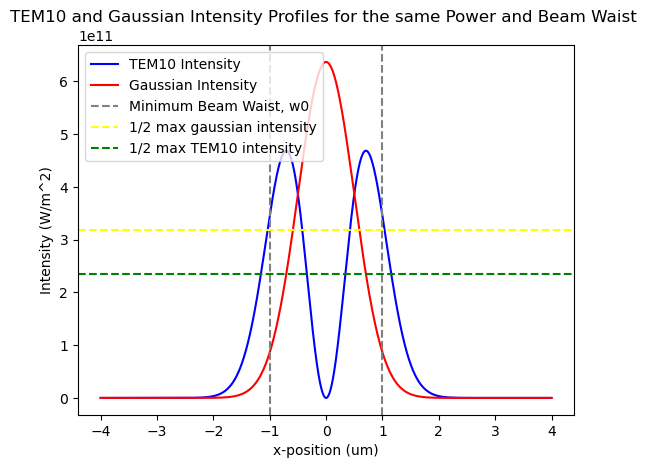

In [51]:
#Now I just want to see what the TEM10 and Gaussian beams look like
plt.xlabel("x-position (um)")
plt.ylabel("Intensity (W/m^2)") 
plt.plot(x_pos*1e6,TEM10,'b-',label = "TEM10 Intensity")
plt.legend(loc = 'upper right')
plt.plot(x_pos*1e6,gaussian_intensity,'r-',label = "Gaussian Intensity")
plt.axvline(x = w0*1e6,linestyle = "dashed",color = "gray", label = "Minimum Beam Waist, w0")
plt.axvline(x = -w0*1e6,linestyle = "dashed", color = "gray")
plt.axhline(y = max(gaussian_intensity)/2,linestyle = "dashed",color = "yellow",label = "1/2 max gaussian intensity")
plt.axhline(y = max(TEM10)/2,linestyle = "dashed",color = "green",label = "1/2 max TEM10 intensity")
plt.legend(loc = "best")
plt.title("TEM10 and Gaussian Intensity Profiles for the same Power and Beam Waist ")
plt.show()

In [52]:
find_fwhm_gaussian = np.where(np.isclose(max(gaussian_intensity)/2, gaussian_intensity, atol=5e5))

if len(find_fwhm_gaussian[0]) > 1:  # Ensure there are at least two indices
	fwhm_gaussian = x_pos[find_fwhm_gaussian][1] - x_pos[find_fwhm_gaussian][0]
	print(gaussian_intensity[find_fwhm_gaussian])
	print(max(gaussian_intensity)/2)
	print(find_fwhm_gaussian)
	print(fwhm_gaussian/w0)
else:
	print("No valid indices found for FWHM calculation.")

No valid indices found for FWHM calculation.


In [53]:
find_fwhm_tem = np.where(np.isclose(max(TEM10)/2,TEM10,atol = 5e5))
fwhm_tem = [x_pos[find_fwhm_tem][1] - x_pos[find_fwhm_tem][0],x_pos[find_fwhm_tem][3]-x_pos[find_fwhm_tem][2]]
print(TEM10[np.where(np.isclose(max(TEM10)/2,TEM10,atol = 5e5))])
print(max(TEM10)/2)
print(fwhm_tem)
print(fwhm_tem[0]/w0)

IndexError: index 1 is out of bounds for axis 0 with size 0

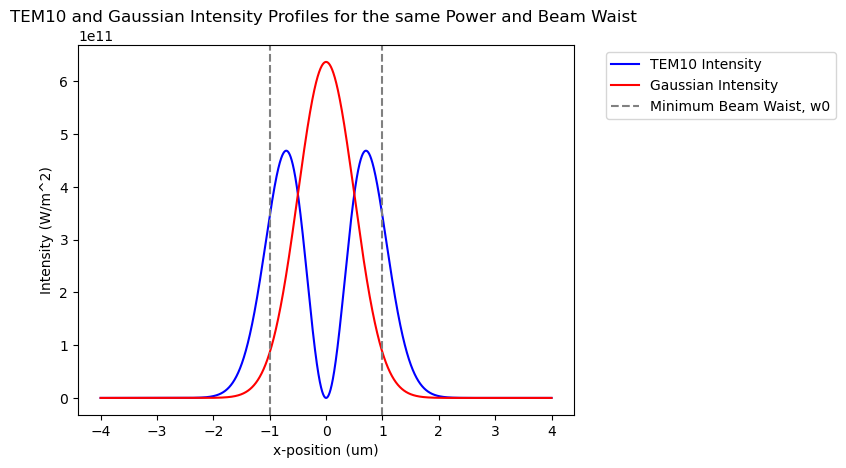

In [54]:
#Now I just want to see what the TEM10 and Gaussian beams look like
plt.xlabel("x-position (um)")
plt.ylabel("Intensity (W/m^2)") 
plt.plot(x_pos*1e6,TEM10,'b-',label = "TEM10 Intensity")
plt.legend(loc = 'upper right')
plt.plot(x_pos*1e6,gaussian_intensity,'r-',label = "Gaussian Intensity")
plt.axvline(x = w0*1e6,linestyle = "dashed",color = "gray", label = "Minimum Beam Waist, w0")
plt.axvline(x = -w0*1e6,linestyle = "dashed", color = "gray")
"""plt.axvline(x =x_pos[find_fwhm_gaussian][1]*1e6 ,linestyle = "dashed", color = "yellow",label = "FWHM Gaussian")
plt.axvline(x =x_pos[find_fwhm_gaussian][0]*1e6 ,linestyle = "dashed", color = "yellow")
plt.axvline(x = x_pos[find_fwhm_tem][1]*1e6,linestyle = "dashed", color = "green",label = "FWHM TEM10")
plt.axvline(x = x_pos[find_fwhm_tem][0]*1e6,linestyle = "dashed", color = "green")
plt.axvline(x = x_pos[find_fwhm_tem][3]*1e6,linestyle = "dashed", color = "green")
plt.axvline(x = x_pos[find_fwhm_tem][2]*1e6,linestyle = "dashed", color = "green")
plt.axhline(y = max(TEM10)/2,linestyle = "dashed", color = "gray")"""
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("TEM10 and Gaussian Intensity Profiles for the same Power and Beam Waist ")
plt.show()

In [55]:
mid_variable = np.where(np.isclose(max(TEM10),TEM10,atol = 5e5))[0]
print(mid_variable)
center = x_pos[mid_variable][0]


[3292 3293 3294 4706 4707 4708]


R-Squared value 0.9997466003218279
Fit Frequency [2 Pi x kHz] 983.3870381729721
Analytical Frequency [2 Pi x MHz] 1.0098703958516895
Ratio of Fit to Analytical Frequencies  0.9737754886295262


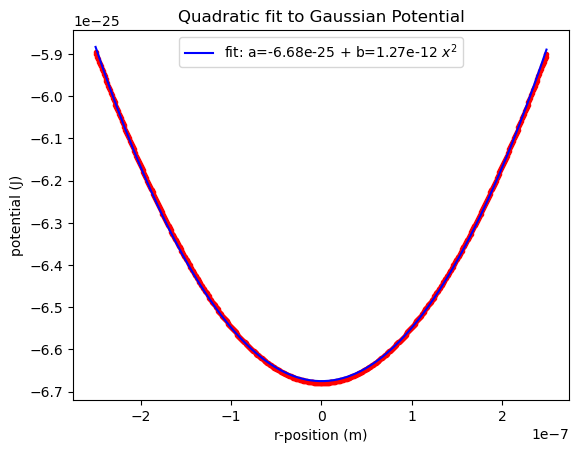

In [60]:
#ok now I want to find the fits for both the gaussian beam and for the tem10 beam 
P0 = 1
x_pos = np.arange(-(0.25)*w0,(0.25)*w0,0.001e-6)
gaussian_intensity = intensity(x_pos,y_pos,P0, wz)
gaussian_potential =  potential_position_dependent(omega_res,linewidths,omega_tweezer,gaussian_intensity)  
def quadratic(x,a,b):
    return a+b*(x**2)
xdata = x_pos
ydata = gaussian_potential
popt, pcov = curve_fit(quadratic, xdata, ydata)
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  quadratic(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
fit = np.sqrt(2*popt[1]/m)
print("Fit Frequency [2 Pi x kHz]",fit*1e-3 / (2*pi))
U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
test = tweezer_optical_potential_to_trap_frequency(tweezer_wavelength,linewidths,omega_res,P0,w0,m,U)
print("Analytical Frequency [2 Pi x MHz]",test[0]*1e-6/(2*pi))
print("Ratio of Fit to Analytical Frequencies ",fit/test[0])

plt.plot(xdata,ydata,'r.')
plt.plot(xdata,quadratic(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (m)")
plt.ylabel("potential (J)")
plt.title("Quadratic fit to Gaussian Potential")
plt.legend()
plt.show()

249.99999999999994
R-Squared value 0.9991253883241877
[-4.91386832e-25  1.92656066e-12  7.09292294e-07]
Fit Frequency [2Pi MHz] 1.2127605354918514
Center of Node [nm] 709.2922940670751


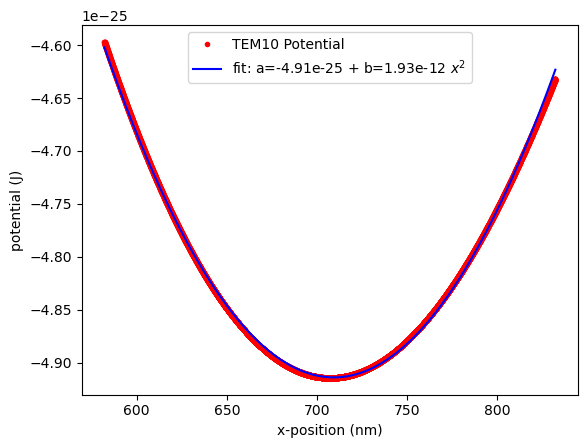

In [57]:
range_width = w0*0.25  # Total range
num_points = 10000  # Define the number of points in the range
center = w0/(np.sqrt(2))
x_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
print((max(x_pos)-min(x_pos))*1e9)
y_pos=0
TEM10 = intensity_TEM10(x_pos,y_pos,w0,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10) 
def fitting_function(x,a,b,x0):
    #x0 = center
    return a + b*(x - x0)**2
xdata = x_pos
ydata = tem10_potential
popt, pcov = curve_fit(fitting_function, xdata, ydata,p0 = [-1.385153-26,6e-14,center]) 
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  fitting_function(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
print(popt)
fit_tem = np.sqrt(2*popt[1]/m)
fit_center = popt[2]
print("Fit Frequency [2Pi MHz]",fit_tem*1e-6 / (2*pi))
print("Center of Node [nm]",popt[2]*1e9)


plt.plot(xdata*1e9,ydata,'r.',label = "TEM10 Potential")
plt.plot(xdata*1e9,fitting_function(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("x-position (nm)")
plt.ylabel("potential (J)")
#plt.title("Quadratic fit to TEM10 Potential - xslice")
plt.legend()
plt.show()

750.0
R-Squared value 0.9987293033147765
Fit Frequency [2Pi kHz] 816.4306973029358
Center of Node [nm] -0.00016390065453132822


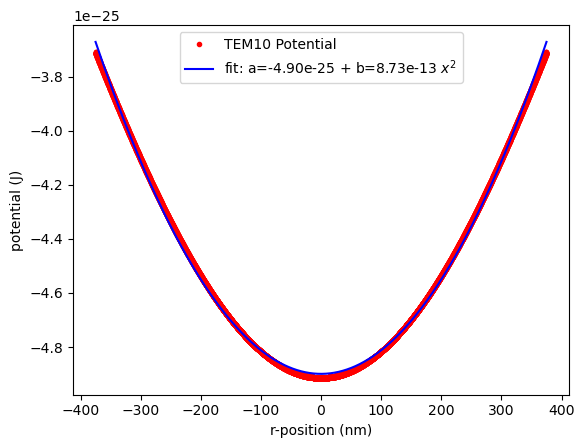

In [ ]:

range_width = w0*0.75  # Total range
num_points = 10000  # Define the number of points in the range
center = 0
y_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
print((max(y_pos)-min(y_pos))*1e9)
x_pos=w0/(np.sqrt(2))
TEM10 = intensity_TEM10(x_pos,y_pos,w0,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10) 
#plt.plot(xdata,ydata,'r.')
def fitting_function(x,a,b,x0):
    #x0 = center
    return a + b*(x - x0)**2
xdata = y_pos
ydata = tem10_potential
popt, pcov = curve_fit(fitting_function, xdata, ydata,p0 = [-1.385153-26,6e-14,center]) 
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  fitting_function(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
fit_tem = np.sqrt(2*popt[1]/m)
fit_center = popt[2]
print("Fit Frequency [2Pi kHz]",fit_tem*1e-3 / (2*pi))
print("Center of Node [nm]",popt[2]*1e9)


plt.plot(xdata*1e9,ydata,'r.',label = "TEM10 Potential")
plt.plot(xdata*1e9,fitting_function(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (nm)")
plt.ylabel("potential (J)")
#plt.title("Quadratic fit to TEM10 Potential - yslice")
plt.legend()
plt.show()

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


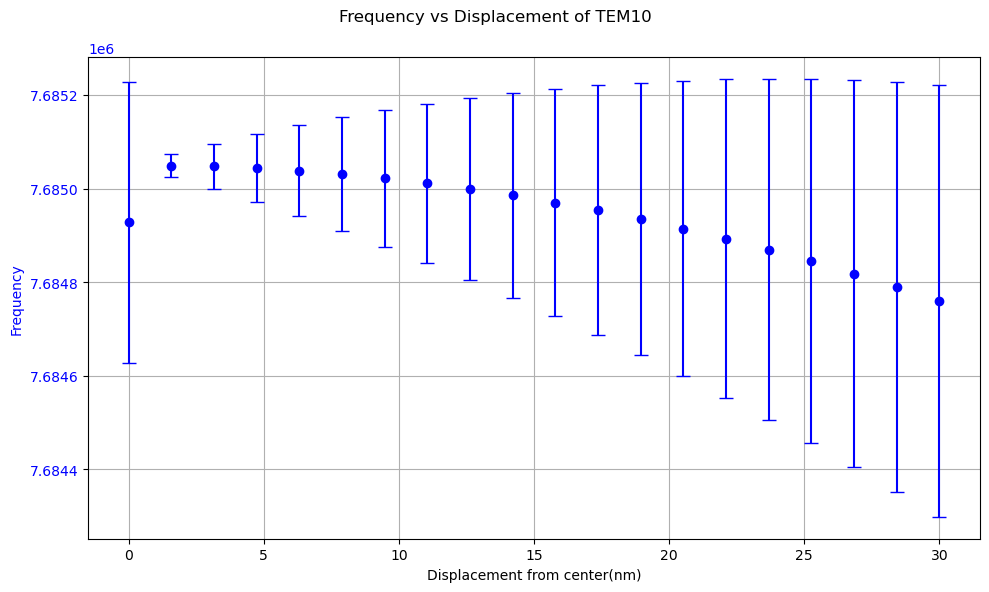

In [58]:
dial_values = np.linspace(0, 0.03, 20)  # Keep the original range
num_points = 1000  # Define the number of points for r_pos
center = fit_center
results, ratios, errors, positions = [], [], [], []
omega_rf_axial = 1 * 2 * pi * 1e6
ionspacing = ion_spacing(1, omega_rf_axial)

for dial in dial_values:
    if dial == 0:
        range_width = 0.001e-5
    else:
        range_width = (w0 / 2) * (dial + dial * 0.025)
    
    x_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
    TEM10 = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, TEM10) 
    
    popt, pcov = curve_fit(fitting_function, x_pos, ydata, p0=[-1.385153e-26, 6e-14, center])
    fit_frequency = np.sqrt(2 * popt[1] / m)
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit_frequency * (perr[1] / popt[1]))
    
    displacement = w0 * dial  # Keep displacement as is
    omega_tw_radial = fit_frequency
      # Solve for tweezer-on position with fsolve
    tweeze_on, info, ier, msg = fsolve(
        pot_derivative_with_tweeze, 
        ionspacing[0], 
        args=(omega_rf_axial, omega_tw_radial, [0], displacement), 
        full_output=True
    )
    # Check if fsolve succeeded
    if ier != 1:
        print(f"⚠️ Warning: fsolve did not converge for dial={dial:.2f}. Message: {msg}")
        tweeze_on = [ionspacing[0]]  # Default to initial guess if fsolve fails
    


    positions.append(tweeze_on[0])
    
    results.append((dial, fit_frequency))
    ratios.append(fit_frequency)
    errors.append(fit_error)

positions = np.array(positions) * 1e9  # Convert to nm
print(positions)
displacements_nm = dial_values * w0 * 1e9  # Convert displacement to um for x-axis

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot frequency with errors
ax1.errorbar(displacements_nm, ratios, yerr=errors, fmt='o', label='Fit Frequency', color='blue', capsize=5)  
ax1.set_xlabel('Displacement from center(nm)')  
ax1.set_ylabel('Frequency', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Highlight the center point (dial == 0)
#center_index = np.argmin(np.abs(dial_values))  # Find the index closest to zero
#ax1.scatter(displacements_nm[center_index], ratios[center_index], color='black', edgecolors='white', s=100, label='Center Point', zorder=3)

# Second y-axis for ion position
"""ax2 = ax1.twinx()
ax2.plot(displacements_nm, positions, 'o', color='red', label='Ion Position')  
ax2.set_ylabel('Ion Position (nm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')"""

fig.suptitle('Frequency vs Displacement of TEM10')
ax1.grid(True)
fig.tight_layout()
plt.show()


In [46]:
from IPython.display import display, Markdown

# Create a DataFrame for the Gaussian table
data_gaussian = {
    'Column 1': ['w0 [um]', 'FWHM [um]', 'Power [W]', r'$\theta_{x}\degree$', r'$\omega_{x}$ [2Pi MHz]'],
    'Column 2': [w0*1e6, w0*1.18*1e6, power_gaussian, theta_gaussian*180/pi, fit*1e-6/(2*pi)]
}

df_table_gaussian = pd.DataFrame(data_gaussian)

# Create a DataFrame for the TEM10 table
data_tem10 = {
    'Column 1': ['w0 [um]', 'FWHM [um]', 'Distance between traps [um]',
                 'Approximate Axial Trap freq required (N=3) [2 Pi Hz]','Power [W]', 
                 r'$\theta_{x}\degree$', r'$\omega_{x}$ [2Pi MHz]'],
    'Column 2': [w0*1e6, w0*0.8*1e6, np.abs(center*2)*1e6,
                 0.5,power_tem, theta_TEM10*180/pi, 
                 fit_tem*1e-6/(2*pi)]
}

df_table_tem10 = pd.DataFrame(data_tem10)

# Function to convert DataFrame to Markdown table
def df_to_markdown(df):
    return df.to_markdown(index=False)

# Display the tables
print("Gaussian")
display(Markdown(df_to_markdown(df_table_gaussian)))

print("TEM10")
display(Markdown(df_to_markdown(df_table_tem10)))

Gaussian


| Column 1               |   Column 2 |
|:-----------------------|-----------:|
| w0 [um]                |   1        |
| FWHM [um]              |   1.18     |
| Power [W]              |   1        |
| $\theta_{x}\degree$    |   9.70252  |
| $\omega_{x}$ [2Pi MHz] |   0.983387 |

TEM10


| Column 1                                             |     Column 2 |
|:-----------------------------------------------------|-------------:|
| w0 [um]                                              |  1           |
| FWHM [um]                                            |  0.8         |
| Distance between traps [um]                          |  3.27801e-07 |
| Approximate Axial Trap freq required (N=3) [2 Pi Hz] |  0.5         |
| Power [W]                                            |  1           |
| $\theta_{x}\degree$                                  | 29.1075      |
| $\omega_{x}$ [2Pi MHz]                               |  0.816431    |

In [47]:
N = 9
omega_a = 2e6*2*pi
spacing = ion_spacing(N,omega_a)
print(spacing)


[array([-7.51201532e-06, -5.29629866e-06, -3.41784587e-06, -1.68044447e-06,
       -2.66488579e-18,  1.68044447e-06,  3.41784587e-06,  5.29629866e-06,
        7.51201532e-06]), [2.2157166594279797e-06, 1.8784527862813144e-06, 1.737401404044085e-06, 1.680444470045181e-06, 1.6804444700452002e-06, 1.7374014040432818e-06, 1.8784527862772419e-06, 2.215716659462443e-06]]


In [ ]:
N = 3
tweezed_ions = [0,1]
omega_a = 0.5e6*2*pi*np.ones(N)
omega_tweezer_r = np.zeros(N)
omega_tweezer_r[tweezed_ions] = fit_tem
omega_combined_ar = np.sqrt(omega_tweezer_r**2 + omega_a**2)
ueq = ion_spacing(N,omega_a)[0]
ar_modes = mode_calc_a(m,omega_combined_ar,ueq,N)
base = mode_calc_a(m,omega_a,ueq,N)

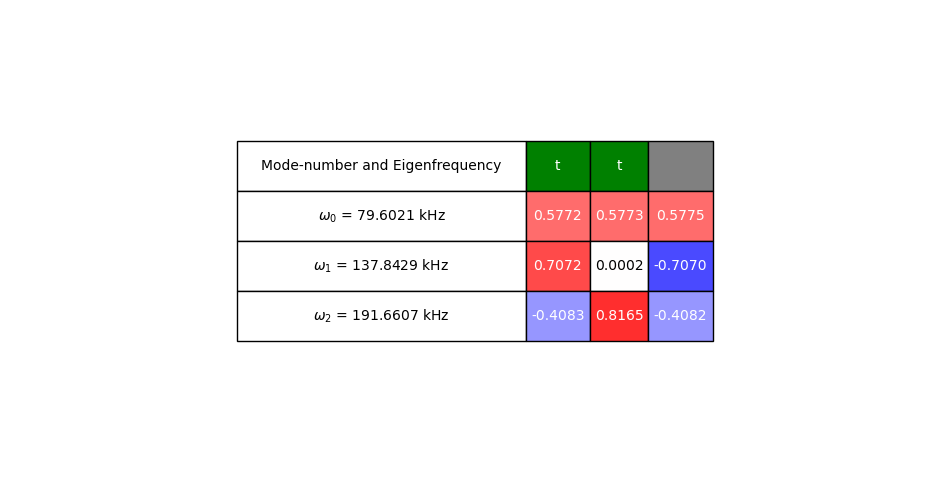

In [ ]:
import matplotlib.colors as mcolors
data = ar_modes

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 2 * len(data)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(data):
    # Convert omega from radians per second to kHz
    omega_mhz = (omega / (2 * np.pi)) / 1e3
    formatted_values = [f"{value:.4f}" for value in values]
    omega_label = f"$\omega_{{{index}}}$ = {omega_mhz:.4f} kHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels

column_labels = ['Mode-number and Eigenfrequency']  # Start with the label for the frequency column
for i in range(len(data[0][1])):
    if i  in [0,1]:  # These columns will have 't'
        column_labels.append('t')
    else:
        column_labels.append(' ')  # Other columns remain blank
# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(data[0][1]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-1, vmax=1)

light_gray_columns = [2]
# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.3 < value < 0.3 else 'white')

# Special coloring for the first row
light_gray_columns = [0,1,2]
for j in range(1, len(column_labels)):  # Start from 1 to skip the first cell
    if j in light_gray_columns:
        table[0, j].set_facecolor('green')  # Set specified columns' background to blue
        table[0,j].set_text_props(color = 'white')
    else:
        table[0, j].set_facecolor('gray')  # Set other columns' background to gray
table[0, 0].set_facecolor('white')  # Set top left corner cell background to white

"""# Adjusting specific header cells for borders
for i in range(1, len(colWidths)):
    if i == 2:  # Correct index for m=0
        table[0, i].visible_edges = 'T'  # Top border only
    elif i == len(colWidths) - 1:  # Correct index for m=16
        table[0, i].visible_edges = 'TR'  # Top and Right borders
    else:
        table[0, i].visible_edges = 'T'  # Only top border for other cells"""

#plt.savefig("17_ions_modes_tweezed_table.png")
plt.show()

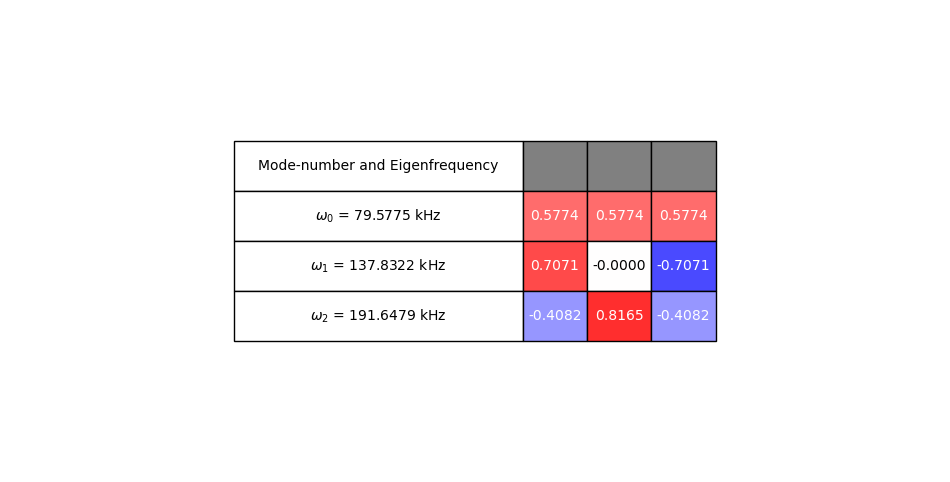

In [ ]:
data = base

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 2 * len(data)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(data):
    # Convert omega from radians per second to kHz
    omega_mhz = (omega / (2 * np.pi)) / 1e3
    formatted_values = [f"{value:.4f}" for value in values]
    omega_label = f"$\omega_{{{index}}}$ = {omega_mhz:.4f} kHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Mode-number and Eigenfrequency'] + [" " for i in range(len(data[0][1]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(data[0][1]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.3 < value < 0.3 else 'white')

# Set gold background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('gray')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

#plt.savefig("17_ions_modes_table.png")
plt.show()

In [ ]:
N = 3
tweezed_ions = [0,1]
omega_a = 0.5e6*2*pi*np.ones(N)
omega_tweezer_r = np.zeros(N)
omega_tweezer_r[tweezed_ions] = fit
omega_combined_ar = np.sqrt(omega_tweezer_r**2 + omega_a**2)
ueq = ion_spacing(N,omega_a)[0]
ar_modes_gaussian = mode_calc_a(m,omega_combined_ar,ueq,N)


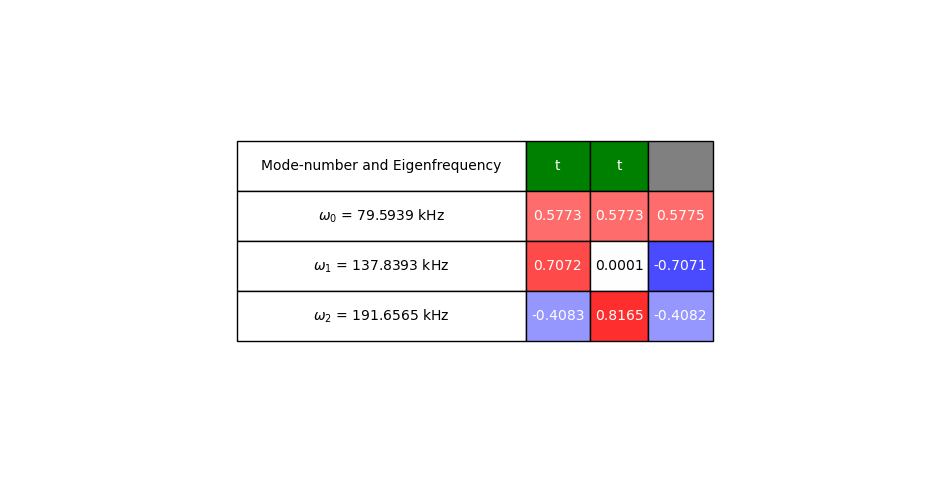

In [ ]:
data = ar_modes_gaussian

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 2 * len(data)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(data):
    # Convert omega from radians per second to kHz
    omega_mhz = (omega / (2 * np.pi)) / 1e3
    formatted_values = [f"{value:.4f}" for value in values]
    omega_label = f"$\omega_{{{index}}}$ = {omega_mhz:.4f} kHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels

column_labels = ['Mode-number and Eigenfrequency']  # Start with the label for the frequency column
for i in range(len(data[0][1])):
    if i  in [0,1]:  # These columns will have 't'
        column_labels.append('t')
    else:
        column_labels.append(' ')  # Other columns remain blank
# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(data[0][1]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-1, vmax=1)

light_gray_columns = [2]
# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.3 < value < 0.3 else 'white')

# Special coloring for the first row
light_gray_columns = [0,1,2]
for j in range(1, len(column_labels)):  # Start from 1 to skip the first cell
    if j in light_gray_columns:
        table[0, j].set_facecolor('green')  # Set specified columns' background to blue
        table[0,j].set_text_props(color = 'white')
    else:
        table[0, j].set_facecolor('gray')  # Set other columns' background to gray
table[0, 0].set_facecolor('white')  # Set top left corner cell background to white

"""# Adjusting specific header cells for borders
for i in range(1, len(colWidths)):
    if i == 2:  # Correct index for m=0
        table[0, i].visible_edges = 'T'  # Top border only
    elif i == len(colWidths) - 1:  # Correct index for m=16
        table[0, i].visible_edges = 'TR'  # Top and Right borders
    else:
        table[0, i].visible_edges = 'T'  # Only top border for other cells"""

#plt.savefig("17_ions_modes_tweezed_table.png")
plt.show()

In [ ]:
w0 = 1e-6
wz = beam_propogation(w0,0,tweezer_wavelength)
P0 = 1

sca_gauss = scattering_position_dependent(omega_res, linewidths, omega_tweezer, intensity(0,0,P0,wz))
scat = scattering(omega_tweezer,linewidths,omega_res,P0,w0)
sca_tem = scattering_position_dependent(omega_res, linewidths, omega_tweezer, max(TEM10))
freq_TEM_x = TEM10_tweezer_optical_potential_to_trap_frequency_x(linewidths, omega_res,omega_tweezer, w0, m, P0) / (2 * pi)
freq_TEM_y = TEM10_tweezer_optical_potential_to_trap_frequency_y(linewidths, omega_res,omega_tweezer, w0, m, P0) / (2 * pi)
print(freq_TEM_x, freq_TEM_y)
print(sca_gauss,scat)

nan [nan nan]
110.84676107560175 110.84676107560176


/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:313: RuntimeWarning: invalid value encountered in sqrt
  p.append(np.sqrt(
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:303: RuntimeWarning: invalid value encountered in sqrt
  p.append(np.sqrt(


In [ ]:
Popt = 100*1e-3
w0s = np.linspace(0.05,7,200)*1e-6
beam_div_tem = half_angle_beam_divergence(3,w0s,tweezer_wavelength) * 180/pi
beam_div_gauss = half_angle_beam_divergence(1,w0s,tweezer_wavelength) * 180/pi

U = potential(omega_tweezer,linewidths,omega_res,Popt,w0s[0])
f_tw_g_r = tweezer_optical_potential_to_trap_frequency(tweezer_wavelength,linewidths,omega_res,Popt,w0s,m,U)[0] / (2*pi)
sca_g = scattering(omega_tweezer,linewidths,omega_res,Popt,w0s)

TEM10 = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
tem10_potential = potential_position_dependent(omega_res, linewidths, omega_tweezer, TEM10)
#f_tw_tem_x = TEM10_tweezer_optical_potential_to_trap_frequency_x(linewidths, omega_res, omega_tweezer, w0s, m, Popt) / (2 * pi)
#f_tw_tem_y = TEM10_tweezer_optical_potential_to_trap_frequency_y(linewidths, omega_res, omega_tweezer, w0s, m, Popt) / (2 * pi)
#sca_tem = scattering_position_dependent(omega_res, linewidths, omega_tweezer, TEM10)

In [ ]:
# Find indices where beam_div is close to 6 and close to 39
indices_close_to_6 = np.where(np.isclose(beam_div_gauss, 6, atol=0.1))[0]
indices_close_to_39 = np.where(np.isclose(beam_div_gauss, 39, atol=5))[0]

print("Indices where beam_div is close to 6:", indices_close_to_6)
print("Indices where beam_div is close to 39:", indices_close_to_39)
print(w0s[indices_close_to_6], w0s[indices_close_to_39])

Indices where beam_div is close to 6: [45]
Indices where beam_div is close to 39: [5 6]
[1.62160804e-06] [2.24623116e-07 2.59547739e-07]


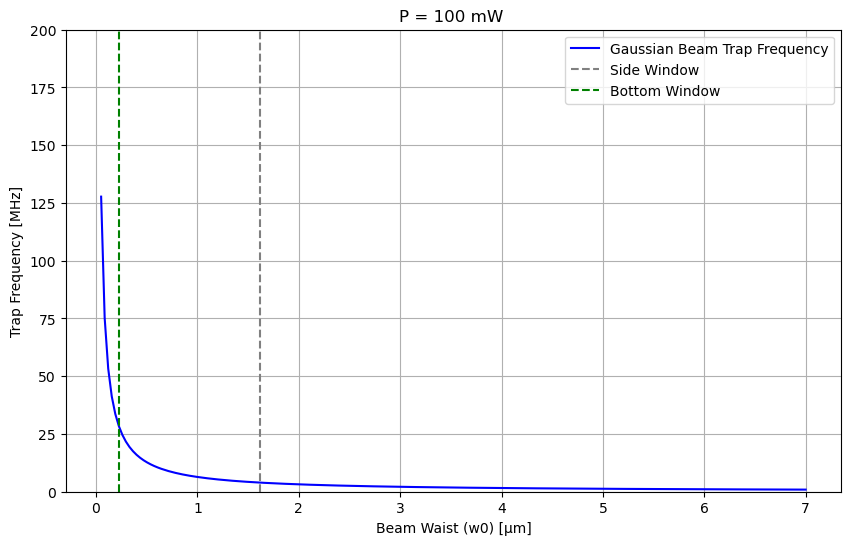

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(w0s * 1e6, f_tw_g_r*1e-6, label='Gaussian Beam Trap Frequency', color='blue')
#plt.plot(w0s * 1e6, f_tw_tem_x*1e-6, label='TEM10 Beam Trap Frequency', color='red')
plt.axvline(w0s[indices_close_to_6][0]*1e6,linestyle = "dashed",color = "gray", label = "Side Window")
plt.axvline(w0s[indices_close_to_39][0]*1e6,linestyle = "dashed",color = "green",label = "Bottom Window")
plt.xlabel('Beam Waist (w0) [µm]')
plt.ylabel('Trap Frequency [MHz]')
plt.ylim(0,200)
plt.title('P = 100 mW ')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'f_tw_tem_y' is not defined

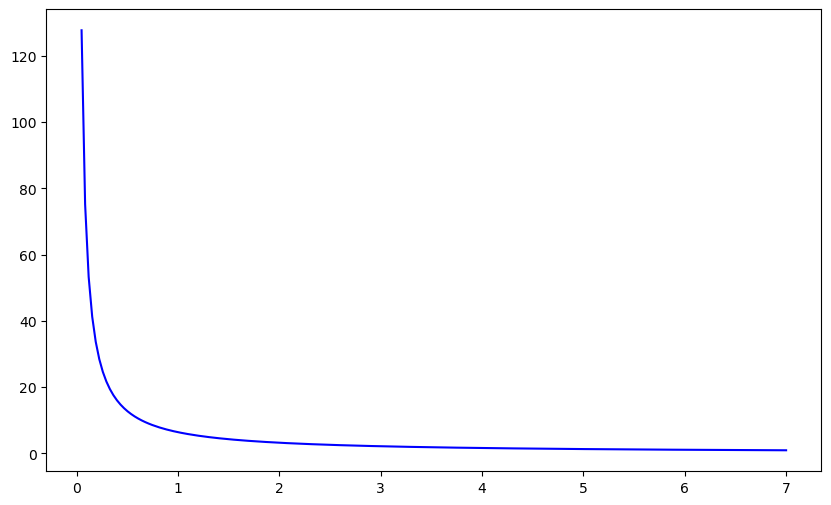

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(w0s * 1e6, f_tw_g_r*1e-6, label='Gaussian Beam Trap Frequency', color='blue')
plt.plot(w0s * 1e6, f_tw_tem_y*1e-6, label='TEM10 Beam Trap Frequency', color='red')
plt.axvline(w0s[indices_close_to_6][0]*1e6,linestyle = "dashed",color = "gray", label = "Side Window")
plt.axvline(w0s[indices_close_to_39][0]*1e6,linestyle = "dashed",color = "green",label = "Bottom Window")
plt.xlabel('Beam Waist (w0) [µm]')
plt.ylabel('Trap Frequency [MHz]')
#plt.ylim(0,1.5)
plt.title('P = 100 mW ')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#TEM intensity taylor expansion
def TEM10_intensity_Taylor_right(wz,P0,x_pos,y_pos):
    e = np.exp(1)
    x0y0 = ((P0)/(e * pi * wz**2)) * (-2/3)
    x2 = ((P0)/(e* pi * wz**4)) * (40)
    x3 = ((P0)/(e*pi*wz**5)) * ((-128*np.sqrt(2) )/3)
    x4 = ((P0)/(e * pi * wz**6)) * (24)
    y2 = ((P0)/(e * pi * wz**4)) *(8)
    xy2 = ((P0 )/(e * pi* wz**5)) * (-32 * np.sqrt(2))
    x2y2 = ((P0 )/(e*pi*wz**6)) * (32)
    y4 = ((P0)/(e * pi *wz**6)) * (8)
    return x0y0 + x2*x_pos**2 + x3*x_pos**3 + x4*x_pos**4 + y2*y_pos**2 + xy2*x_pos * y_pos**2 + x2y2*x_pos**2*y_pos**2 + y4*y_pos**4

def TEM10_intensity_Taylor_left(wz,P0,x_pos,y_pos):
    e = np.exp(1)
    x0y0 = ((P0)/(e * pi * wz**2)) * (-2/3)
    x2 = ((P0)/(e* pi * wz**4)) * (40)
    x3 = ((P0)/(e*pi*wz**5)) * ((128*np.sqrt(2) )/3)
    x4 = ((P0)/(e * pi * wz**6)) * (24)
    y2 = ((P0)/(e * pi * wz**4)) *(8)
    xy2 = ((P0 )/(e * pi* wz**5)) * (32 * np.sqrt(2))
    x2y2 = ((P0 )/(e*pi*wz**6)) * (32)
    y4 = ((P0)/(e * pi *wz**6)) * (8)
    return x0y0 + x2*x_pos**2 + x3*x_pos**3 + x4*x_pos**4 + y2*y_pos**2 + xy2*x_pos * y_pos**2 + x2y2*x_pos**2*y_pos**2 + y4*y_pos**4


def Gaussian_intensity_Talor_y(w0,P0,x_pos,y_pos):
    x_0_y_0 = ((2*P0)/(pi*(w0**2)) )
    x_2_y_0 = (-4*P0*x_pos**2)/(pi*w0**4)
    x_4_y_0 = (4*P0*x_pos**4)/(pi*w0**6)
    y_2 = (-4*P0*y_pos**2)/(pi*w0**4)
    x_2_y_2 = (8*P0*x_pos**2*y_pos**2)/(pi*w0**6)
    x_4_y_2 = (-8*P0*x_pos**4*y_pos**2)/(pi*w0**8)
    y_4 = (4*P0*y_pos**4)/(pi*w0**6)
    x_2_y_4 = (-8*P0*x_pos**2*y_pos**4)/(pi*w0**8)
    x_4_y_4 = (8*P0*x_pos**4*y_pos**4)/(pi*w0**10)
    return x_0_y_0 + x_2_y_0 + x_4_y_0 + y_2 + x_2_y_2 + x_4_y_2 + y_4 + x_2_y_4 + x_4_y_4

def TEM10_coefficnents_Taylor_right(wz,P0,x_pos,y_pos):
    e = np.exp(1)
    x0y0 = ((P0)/(e * pi * wz**2)) * (-2/3)
    x2 = ((P0)/(e* pi * wz**4)) * (40)
    x3 = ((P0)/(e*pi*wz**5)) * ((-128*np.sqrt(2) )/3)
    x4 = ((P0)/(e * pi * wz**6)) * (24)
    y2 = ((P0)/(e * pi * wz**4)) *(8)
    xy2 = ((P0 )/(e * pi* wz**5)) * (-32 * np.sqrt(2))
    x2y2 = ((P0 )/(e*pi*wz**6)) * (32)
    y4 = ((P0)/(e * pi *wz**6)) * (8)
    return [x0y0,x2,x3,x4,y2,xy2,x2y2,y4]
def TEM10_coefficnents_Taylor_left(wz,P0,x_pos,y_pos):
    e = np.exp(1)
    x0y0 = ((P0)/(e * pi * wz**2)) * (-2/3)
    x2 = ((P0)/(e* pi * wz**4)) * (40)
    x3 = ((P0)/(e*pi*wz**5)) * ((128*np.sqrt(2) )/3)
    x4 = ((P0)/(e * pi * wz**6)) * (24)
    y2 = ((P0)/(e * pi * wz**4)) *(8)
    xy2 = ((P0 )/(e * pi* wz**5)) * (32 * np.sqrt(2))
    x2y2 = ((P0 )/(e*pi*wz**6)) * (32)
    y4 = ((P0)/(e * pi *wz**6)) * (8)
    return [x0y0,x2,x3,x4,y2,xy2,x2y2,y4]



In [ ]:
"""w0 = 1e-6
P0 = 1
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))"""
z_pos = 0
tweezer_wavelength = 532e-9
wz = w0
x =w0 / np.sqrt(2)
y = 0
n = 1
tem10_intensity_taylor = TEM10_intensity_Taylor_right(wz, P0, x, y)
tem10_intensity = intensity_TEM10(x, y, w0, wz, E0, n)
potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity_taylor)
potential_real = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity)
print(tem10_intensity_taylor, tem10_intensity)
print(tem10_intensity_taylor/tem10_intensity)
#check the top
print(potential,potential_real)
print(potential == potential_real)

468398652194.55273 468398652194.5534
0.9999999999999986
-4.914387242531567e-25 -4.914387242531574e-25
False


[ 8.19064540e-26 -4.91438724e-12  7.41332596e-06 -2.94863235e+00
 -9.82877449e-13  5.55999447e-06 -3.93150979e+00 -9.82877449e-01]
[x0y0,x2,x3,x4,y2,xy2,x2y2,y4]
[ 9.81743218e-13  4.97077416e-27 -4.91435334e-25 -2.07497719e-13
 -9.28350824e-01]
[ 9.82877448e-13  3.23203669e-27 -4.91438724e-25 -7.67552837e-14
 -9.82877449e-01]


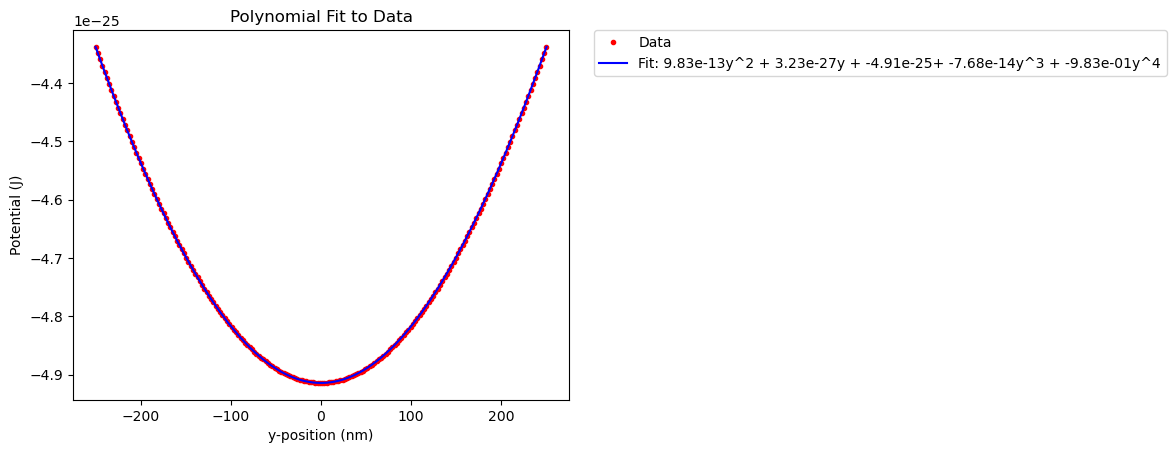

In [ ]:
# Define the parameters
#w0 = 1e-6  # Beam waist in meters
wz = w0
#P0 = 1  # Power in watts
#E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
x_pos = w0/np.sqrt(2)  # x positions from -w0 to w0
dial = 250e-9
y_pos = np.linspace(-dial, +dial, 200)  
tem10_intensity_taylor = TEM10_intensity_Taylor_right(wz,P0, x_pos, y_pos)
tem10_intensity = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity_taylor)
potential_real = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity)

coefficients = TEM10_coefficnents_Taylor_right(wz,P0, x_pos, y_pos)

p = [ (-3.*pi*(c**2.)/(2*(omega_res[0]**3.))) \
                                * (linewidths[0]/((omega_res[0] - omega_tweezer)) +
                                    linewidths[0]/(omega_res[0] + omega_tweezer)) * coefficients[i] for i in range(len(coefficients))]
q = [ (-3.*pi*(c**2.)/(2*(omega_res[1]**3.))) \
                                * (linewidths[1]/((omega_res[1] - omega_tweezer)) +
                                    linewidths[1]/(omega_res[1] + omega_tweezer)) * coefficients[i] for i in range(len(coefficients))]
total = np.array(p) + np.array(q)
print(total)
print("[x0y0,x2,x3,x4,y2,xy2,x2y2,y4]")



# Define the quadratic function
def poly(x, a, b, c,d,e):
    return a * x**2 + b * x + c + d*x**3 + e*x**4
xdata = y_pos
ydata = potential
y_data = potential_real
#p0 = [max(ydata),0,w0]
# Fit the quadratic function to the data
popt, pcov = curve_fit(poly, xdata, ydata)
popt1,pcov1 = curve_fit(poly, xdata, y_data)

# Generate y values based on the fit
y_fit = poly(xdata, *popt)
y_fit1 = poly(xdata, *popt1)
print(popt1)
print(popt)

# Plot the data and the fit
plt.plot(xdata*1e9, ydata, 'r.', label='Data') 
plt.plot(xdata*1e9, y_fit, 'b-', label=f'Fit: {popt[0]:.2e}y^2 + {popt[1]:.2e}y + {popt[2]:.2e}+ {popt[3]:.2e}y^3 + {popt[4]:.2e}y^4')
"""plt.plot(xdata, y_data, 'g.', label='potential real Real')
plt.plot(xdata,y_fit1,'g-', label=f'Fit: {popt1[0]:.2e}x^2 + {popt1[1]:.2e}x + {popt1[2]:.2e}')"""
plt.xlabel("y-position (nm)")
plt.ylabel("Potential (J)")
plt.title("Polynomial Fit to Data")
plt.legend(bbox_to_anchor=(1.05, 1), borderaxespad=0)
plt.show()
#the x^2 term matches with 5th term in the list, and the x^4th term matches with the last one
#5tht term is 


[ 8.19064540e-26 -4.91438724e-12  7.41332596e-06 -2.94863235e+00
 -9.82877449e-13  5.55999447e-06 -3.93150979e+00 -9.82877449e-01]


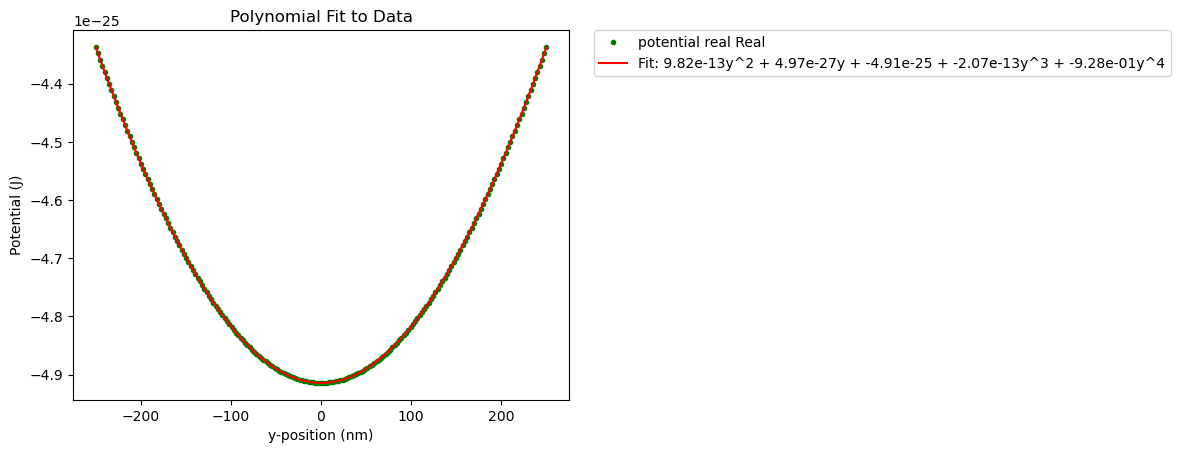

In [ ]:
print(total)
plt.plot(xdata*1e9, y_data, 'g.', label='potential real Real')
plt.plot(xdata*1e9,y_fit1,'r-', label=f'Fit: {popt1[0]:.2e}y^2 + {popt1[1]:.2e}y + {popt1[2]:.2e} + {popt1[3]:.2e}y^3 + {popt1[4]:.2e}y^4')
plt.xlabel("y-position (nm)")
plt.ylabel("Potential (J)")
plt.title("Polynomial Fit to Data")
plt.legend(bbox_to_anchor=(1.05, 1), borderaxespad=0)
plt.show()

[ 8.19064540e-26 -4.91438724e-12  7.41332596e-06 -2.94863235e+00
 -9.82877449e-13  5.55999447e-06 -3.93150979e+00 -9.82877449e-01]
[x0y0,x2,x3,x4,y2,xy2,x2y2,y4]
[-4.91437147e-12 -7.21169174e-24  8.19076661e-26  7.41331092e-06
 -2.94862706e+00]
[-4.83352562e-12  4.80324904e-20  5.87353682e-26  7.16320296e-06
 -2.79976286e+00]


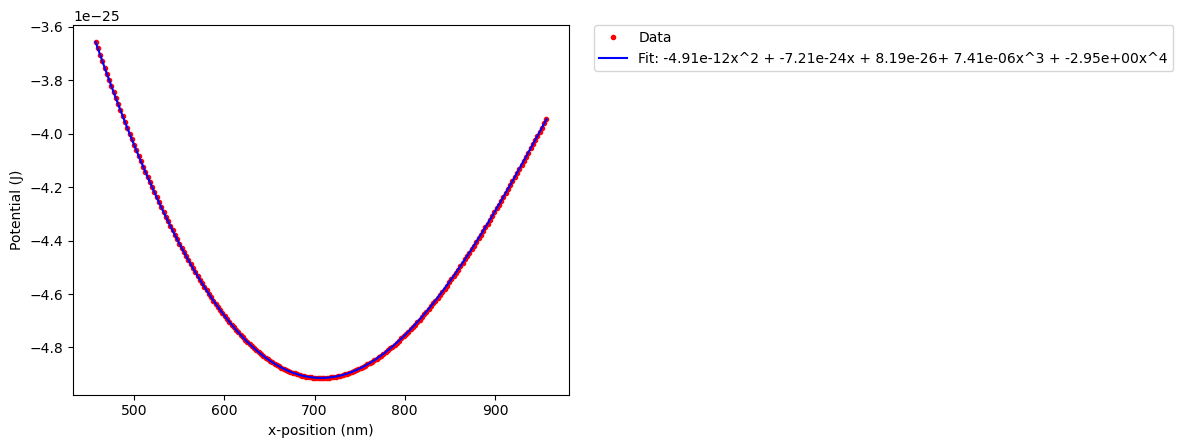

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
wz = w0
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
y_pos = 0 # x positions from -w0 to w0
dial = w0*0.25
x_pos = np.linspace(w0/(np.sqrt(2)) -dial, w0/(np.sqrt(2))+dial,200)  

tem10_intensity_taylor = TEM10_intensity_Taylor_right(wz,P0, x_pos, y_pos)
tem10_intensity = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity_taylor)
potential_real = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity)

coefficients = TEM10_coefficnents_Taylor_right(wz,P0, x_pos, y_pos)

p = [ (-3.*pi*(c**2.)/(2*(omega_res[0]**3.))) \
                                * (linewidths[0]/((omega_res[0] - omega_tweezer)) +
                                    linewidths[0]/(omega_res[0] + omega_tweezer)) * coefficients[i] for i in range(len(coefficients))]
q = [ (-3.*pi*(c**2.)/(2*(omega_res[1]**3.))) \
                                * (linewidths[1]/((omega_res[1] - omega_tweezer)) +
                                    linewidths[1]/(omega_res[1] + omega_tweezer)) * coefficients[i] for i in range(len(coefficients))]
total = np.array(p) + np.array(q)
print(total)
print("[x0y0,x2,x3,x4,y2,xy2,x2y2,y4]")



# Define the quadratic function
def poly(x, a, b, c,d,e):
    return a * x**2 + b * x + c + d*x**3 + e*x**4
xdata = x_pos
ydata = potential
y_data = potential_real
#p0 = [4.83352562e-1,  4.80324904e-20,  5.87353682e-26,  7.16320296e-06,
 #-2.79976286e+00]
# Fit the quadratic function to the data
popt, pcov = curve_fit(poly, xdata, ydata)
popt1,pcov1 = curve_fit(poly, xdata, y_data)

# Generate y values based on the fit
y_fit = poly(xdata, *popt)
y_fit1 = poly(xdata, *popt1)
print(popt)
print(popt1)

# Plot the data and the fit
plt.plot(xdata*1e9, ydata, 'r.', label='Data')
plt.plot(xdata*1e9, y_fit, 'b-', label=f'Fit: {popt[0]:.2e}x^2 + {popt[1]:.2e}x + {popt[2]:.2e}+ {popt[3]:.2e}x^3 + {popt[4]:.2e}x^4')
# plt.plot(xdata, y_data, 'g.', label='potential real Real')
# plt.plot(xdata,y_fit1,'g-', label=f'Fit: {popt1[0]:.2e}x^2 + {popt1[1]:.2e}x + {popt1[2]:.2e}')
plt.xlabel("x-position (nm)")
plt.ylabel("Potential (J)")
#plt.title("Polynomial Fit to Data")
plt.legend(bbox_to_anchor=(1.05, 1), borderaxespad=0)
plt.show()
#the x^2 term matches with 5th term in the list, and the x^4th term matches with the last one
#5tht term is 


[ 8.19064540e-26 -4.91438724e-12  7.41332596e-06 -2.94863235e+00
 -9.82877449e-13  5.55999447e-06 -3.93150979e+00 -9.82877449e-01]


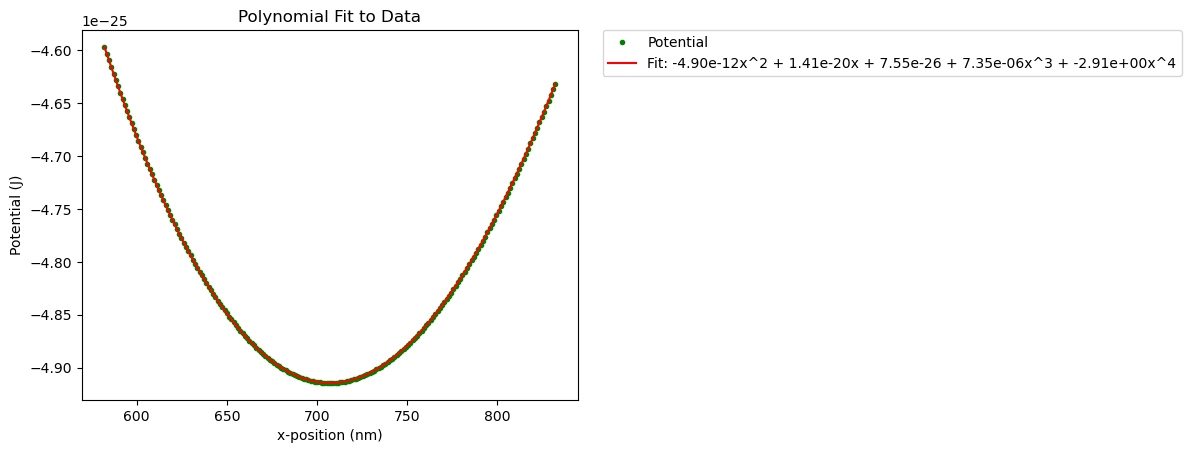

In [ ]:
print(total)
plt.plot(xdata*1e9, y_data, 'g.', label='Potential')
plt.plot(xdata*1e9,y_fit1,'r-', label=f'Fit: {popt1[0]:.2e}x^2 + {popt1[1]:.2e}x + {popt1[2]:.2e} + {popt1[3]:.2e}x^3 + {popt1[4]:.2e}x^4')
plt.xlabel("x-position (nm)")
plt.ylabel("Potential (J)")
plt.title("Polynomial Fit to Data")
plt.legend(bbox_to_anchor=(1.05, 1), borderaxespad=0)
plt.show()

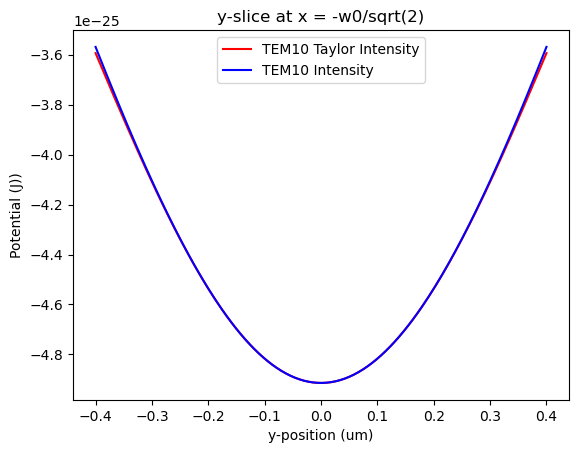

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
wz = w0
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
x_pos = -w0/np.sqrt(2)  # x positions from -w0 to w0
dial = 400e-9
y_pos = np.linspace(-dial, +dial, 200)  
tem10_intensity_taylor = TEM10_intensity_Taylor_left(wz,P0, x_pos, y_pos)
tem10_intensity = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity_taylor)
potential_real = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity)
plt.plot(y_pos*1e6,potential,'r-',label = "TEM10 Taylor Intensity")
plt.plot(y_pos*1e6,potential_real,'b-',label = "TEM10 Intensity")
plt.xlabel("y-position (um)")
plt.ylabel("Potential (J))")
plt.title("y-slice at x = -w0/sqrt(2)")
plt.legend()
plt.show()


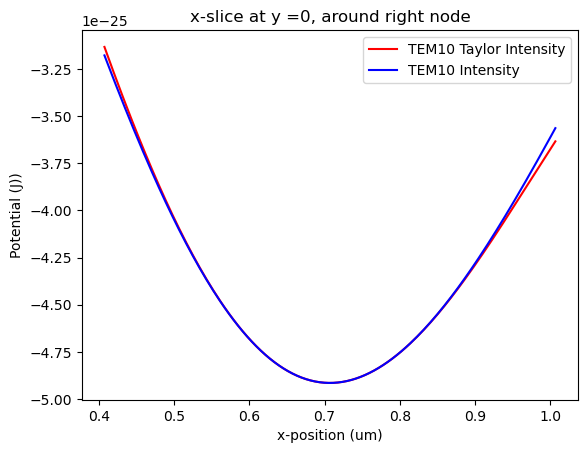

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
wz = w0
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
y_pos = 0  # x positions from -w0 to w0
dial = 300e-9
x_pos = np.linspace(w0/(np.sqrt(2)) -dial, w0/(np.sqrt(2))+dial,200)  
tem10_intensity_taylor = TEM10_intensity_Taylor_right(wz,P0, x_pos, y_pos)
tem10_intensity = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity_taylor)
potential_real = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity)
plt.plot(x_pos*1e6,potential,'r-',label = "TEM10 Taylor Intensity")
plt.plot(x_pos*1e6,potential_real,'b-',label = "TEM10 Intensity")
plt.xlabel("x-position (um)")
plt.ylabel("Potential (J))")
plt.title("x-slice at y =0, around right node")
plt.legend()
plt.show()

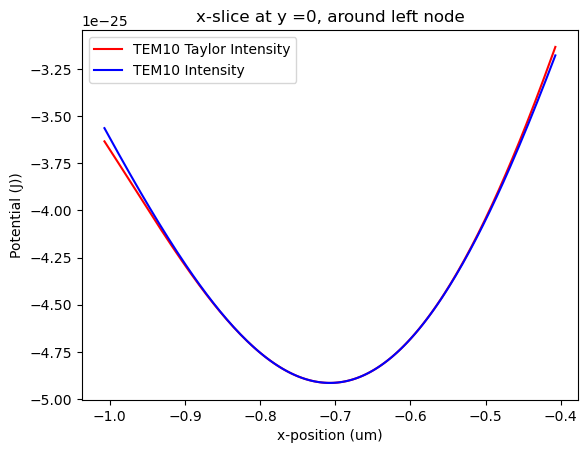

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
wz = w0
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
y_pos = 0  # x positions from -w0 to w0
dial = 300e-9
x_pos = np.linspace(-w0/(np.sqrt(2)) -dial, -w0/(np.sqrt(2))+dial,200)  
tem10_intensity_taylor = TEM10_intensity_Taylor_left(wz,P0, x_pos, y_pos)
tem10_intensity = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity_taylor)
potential_real = potential_position_dependent(omega_res,linewidths,omega_tweezer,tem10_intensity)
plt.plot(x_pos*1e6,potential,'r-',label = "TEM10 Taylor Intensity")
plt.plot(x_pos*1e6,potential_real,'b-',label = "TEM10 Intensity")
plt.xlabel("x-position (um)")
plt.ylabel("Potential (J))")
plt.title("x-slice at y =0, around left node")
plt.legend()
plt.show()

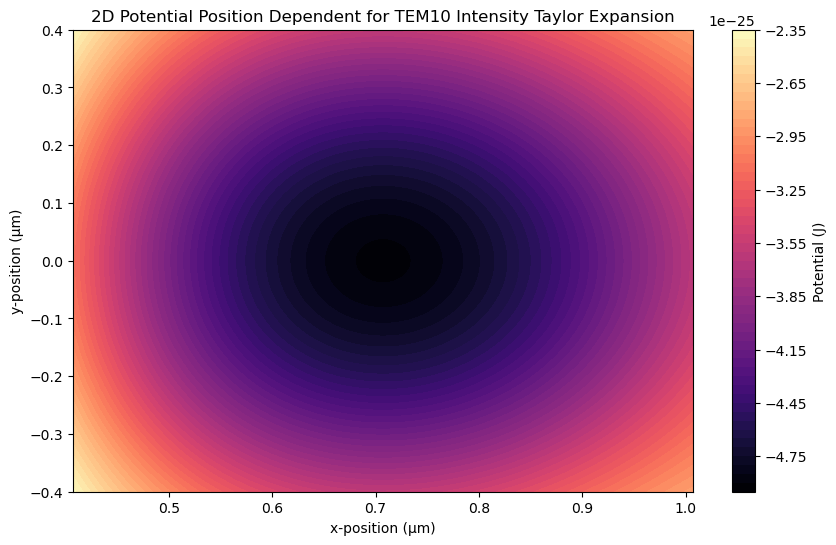

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
wz = w0
dial = 300e-9
x_pos = np.linspace(w0/(np.sqrt(2)) -dial, w0/(np.sqrt(2))+dial,200)  
dial = 400e-9
y_pos = np.linspace(-dial, +dial, 200)  

# Create a meshgrid for x and y positions
X, Y = np.meshgrid(x_pos, y_pos)

# Calculate the TEM10 intensity Taylor expansion for each (x, y) pair
tem10_intensity_taylor = TEM10_intensity_Taylor_right(wz, P0, X, Y)

# Calculate the potential position dependent for each (x, y) pair
potential = potential_position_dependent(omega_res, linewidths, omega_tweezer, tem10_intensity_taylor)

# Plot the 2D potential
plt.figure(figsize=(10, 6))
plt.contourf(X * 1e6, Y * 1e6, potential, levels=50, cmap='magma')
plt.colorbar(label='Potential (J)')
plt.xlabel('x-position (µm)')
plt.ylabel('y-position (µm)')
plt.title('2D Potential Position Dependent for TEM10 Intensity Taylor Expansion')
plt.show()

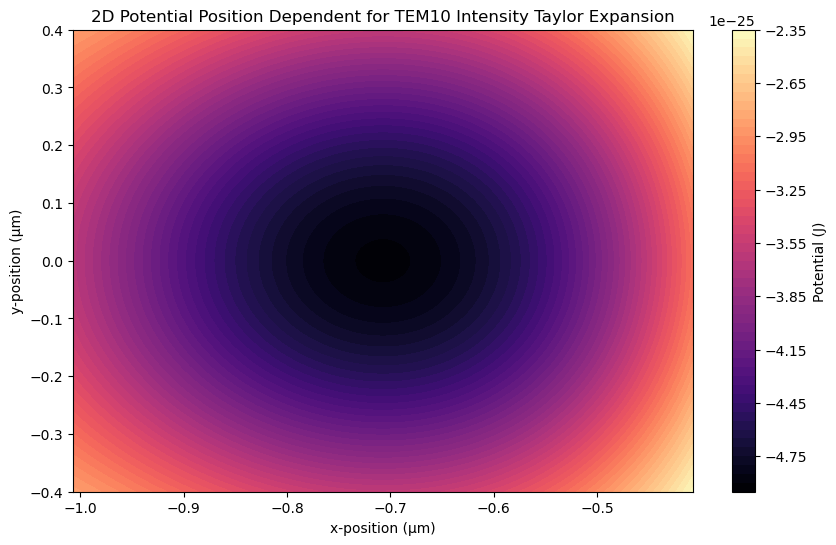

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
wz = w0
dial = 300e-9
x_pos = np.linspace(-w0/(np.sqrt(2)) -dial, -w0/(np.sqrt(2))+dial,200)  
dial = 400e-9
y_pos = np.linspace(-dial, +dial, 200)  

# Create a meshgrid for x and y positions
X, Y = np.meshgrid(x_pos, y_pos)

# Calculate the TEM10 intensity Taylor expansion for each (x, y) pair
tem10_intensity_taylor = TEM10_intensity_Taylor_left(wz, P0, X, Y)

# Calculate the potential position dependent for each (x, y) pair
potential = potential_position_dependent(omega_res, linewidths, omega_tweezer, tem10_intensity_taylor)

# Plot the 2D potential
plt.figure(figsize=(10, 6))
plt.contourf(X * 1e6, Y * 1e6, potential, levels=50, cmap='magma')
plt.colorbar(label='Potential (J)')
plt.xlabel('x-position (µm)')
plt.ylabel('y-position (µm)')
plt.title('2D Potential Position Dependent for TEM10 Intensity Taylor Expansion')
plt.show()

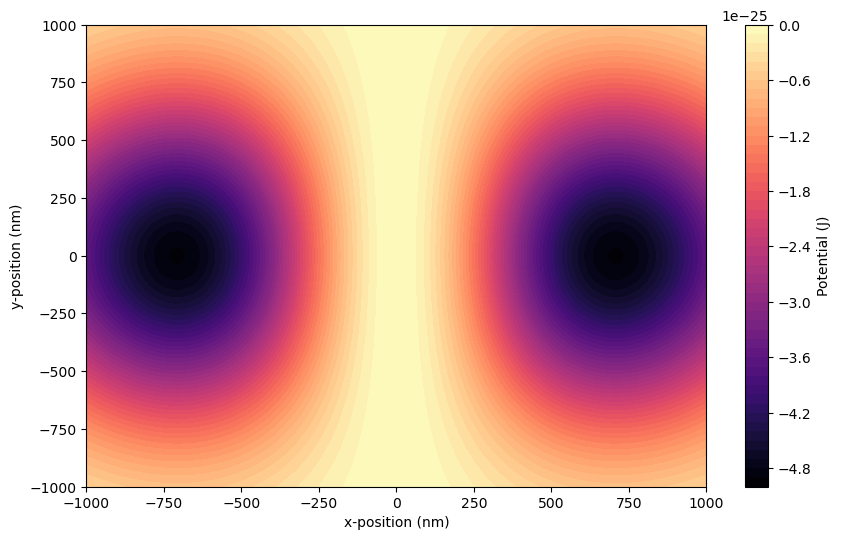

In [ ]:
# Define the parameters
w0 = 1e-6  # Beam waist in meters
wz = w0
P0 = 1  # Power in watts
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*pi))
# dial = 300e-9
# x_pos = np.linspace(w0/(np.sqrt(2)) -dial, w0/(np.sqrt(2))+dial,200)  
# dial = 400e-9
# y_pos = np.linspace(-dial, +dial, 200) 
x_pos = np.linspace(-w0,w0,500)
y_pos = np.linspace(-w0,w0,500)

# Create a meshgrid for x and y positions
X, Y = np.meshgrid(x_pos, y_pos)

# Calculate the TEM10 intensity Taylor expansion for each (x, y) pair
tem10_intensity_taylor = intensity_TEM10(X, Y, w0, wz, E0, n)

# Calculate the potential position dependent for each (x, y) pair
potential = potential_position_dependent(omega_res, linewidths, omega_tweezer, tem10_intensity_taylor)

# Plot the 2D potential
plt.figure(figsize=(10, 6))
plt.contourf(X*1e9 , Y*1e9, potential, levels=50, cmap='magma')
plt.colorbar(label='Potential (J)')
plt.xlabel('x-position (nm)')
plt.ylabel('y-position (nm)')
#plt.title('2D Potential Position Dependent for TEM10 Intensity Taylor Expansion')
plt.show()